# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer,StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
#import ace_tools
#from ace_tools import display_dataframe_to_user



## Data Overview

- Observations
- Sanity checks

In [ ]:
file_path = "/ExtraaLearn.csv"
df = pd.read_csv(file_path)

# 2. Display first few rows
# If you're running this in a Jupyter/Colab notebook, simply writing “df.head(10)” will render a table.
# Otherwise, use print().
print("First 10 Rows of ExtraaLearn:")
print(df.head(10))

# 3. Display dataset shape
print("\nDataset Shape:", df.shape)

# 4. Display data types and non-null counts
print("\nDataFrame Info:")
df.info()   # Note: df.info() already prints to stdout

# 5. Display summary statistics for numeric columns
print("\nSummary Statistics for Numeric Columns:")
print(df.describe())

# 6. Check for missing values
missing_values = df.isnull().sum()
print("\nMissing Values Count per Column:")
print(missing_values)

# 7. Display target variable distribution if present
if 'status' in df.columns:
    print("\nTarget Variable 'status' Distribution:")
    print(df['status'].value_counts())

First 10 Rows of ExtraaLearn:
       ID  age current_occupation first_interaction profile_completed  \
0  EXT001   57         Unemployed           Website              High   
1  EXT002   56       Professional        Mobile App            Medium   
2  EXT003   52       Professional           Website            Medium   
3  EXT004   53         Unemployed           Website              High   
4  EXT005   23            Student           Website              High   
5  EXT006   50         Unemployed        Mobile App              High   
6  EXT007   56       Professional        Mobile App            Medium   
7  EXT008   57       Professional        Mobile App            Medium   
8  EXT009   57       Professional        Mobile App              High   
9  EXT010   59       Professional        Mobile App              High   

   website_visits  time_spent_on_website  page_views_per_visit  \
0               7                   1639                 1.861   
1               2                 

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
# 1. Missing-value check (for illustration)
print("Missing values per column:\n", df.isnull().sum(), "\n")
#no missing values

# 2. Feature Engineering
# 2.1 Convert all "Yes"/"No" marketing columns to binary (0/1)
binary_cols = [
    'print_media_type1',
    'print_media_type2',
    'digital_media',
    'educational_channels',
    'referral'
]
for col in binary_cols:
    df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0})

# 2.2 Create a "total_media_exposures" feature (sum of the five marketing flags)
df['total_media_exposures'] = (
    df['print_media_type1_bin']
    + df['print_media_type2_bin']
    + df['digital_media_bin']
    + df['educational_channels_bin']
    + df['referral_bin']
)

# 2.3 Create an "age_group" categorical feature by binning age
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, np.inf],
    labels=['<30', '30-45', '>45']
)

# 3. Outlier Detection & Treatment
#    Cap 'website_visits' and 'time_spent_on_website' at their 1st/99th percentiles
for col in ['website_visits', 'time_spent_on_website']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

# 4. Drop non-predictive and original Yes/No columns
df = df.drop(columns=['ID'] + binary_cols)

# 5. Separate features and target
X = df.drop(columns=['status'])
y = df['status']

# 6. Split into train & test sets (stratify by target)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. Identify numeric & categorical features for preprocessing
numeric_features = [
    'age',
    'website_visits',
    'time_spent_on_website',
    'page_views_per_visit',
    'total_media_exposures'
]

categorical_features = [
    'current_occupation',
    'first_interaction',
    'profile_completed',
    'last_activity',
    'age_group'
]

# 8. Build preprocessing pipelines
# 8.1 Numeric pipeline: impute missing (if any), log-transform to reduce skew, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

# 8.2 Categorical pipeline: impute missing (mode), then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#9. Combine numeric & categorical pipelines using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# 10. Example: Fit-transform training data, transform test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# 11. For inspection: see the shape after preprocessing
print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_processed.shape)



Missing values per column:
 ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64 

Original X_train shape: (3689, 15)
Transformed X_train shape: (3689, 19)


## EDA

- It is a good idea to explore the data once again after manipulating it.

First 10 rows after feature engineering:
       ID  age current_occupation first_interaction profile_completed  \
0  EXT001   57         Unemployed           Website              High   
1  EXT002   56       Professional        Mobile App            Medium   
2  EXT003   52       Professional           Website            Medium   
3  EXT004   53         Unemployed           Website              High   
4  EXT005   23            Student           Website              High   
5  EXT006   50         Unemployed        Mobile App              High   
6  EXT007   56       Professional        Mobile App            Medium   
7  EXT008   57       Professional        Mobile App            Medium   
8  EXT009   57       Professional        Mobile App              High   
9  EXT010   59       Professional        Mobile App              High   

   website_visits  time_spent_on_website  page_views_per_visit  \
0               7                   1639                 1.861   
1               2      

<ipython-input-58-5d4162361caf>:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grp_conv = df.groupby('age_group')['status'].mean() * 100


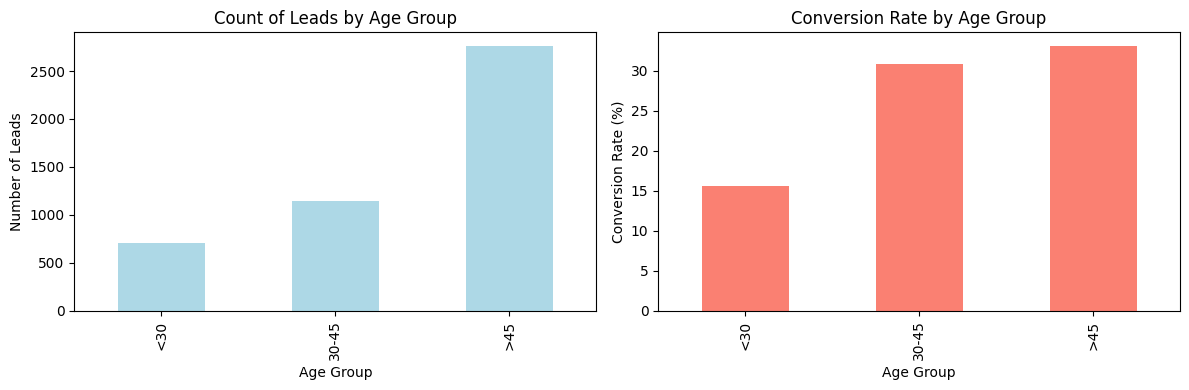

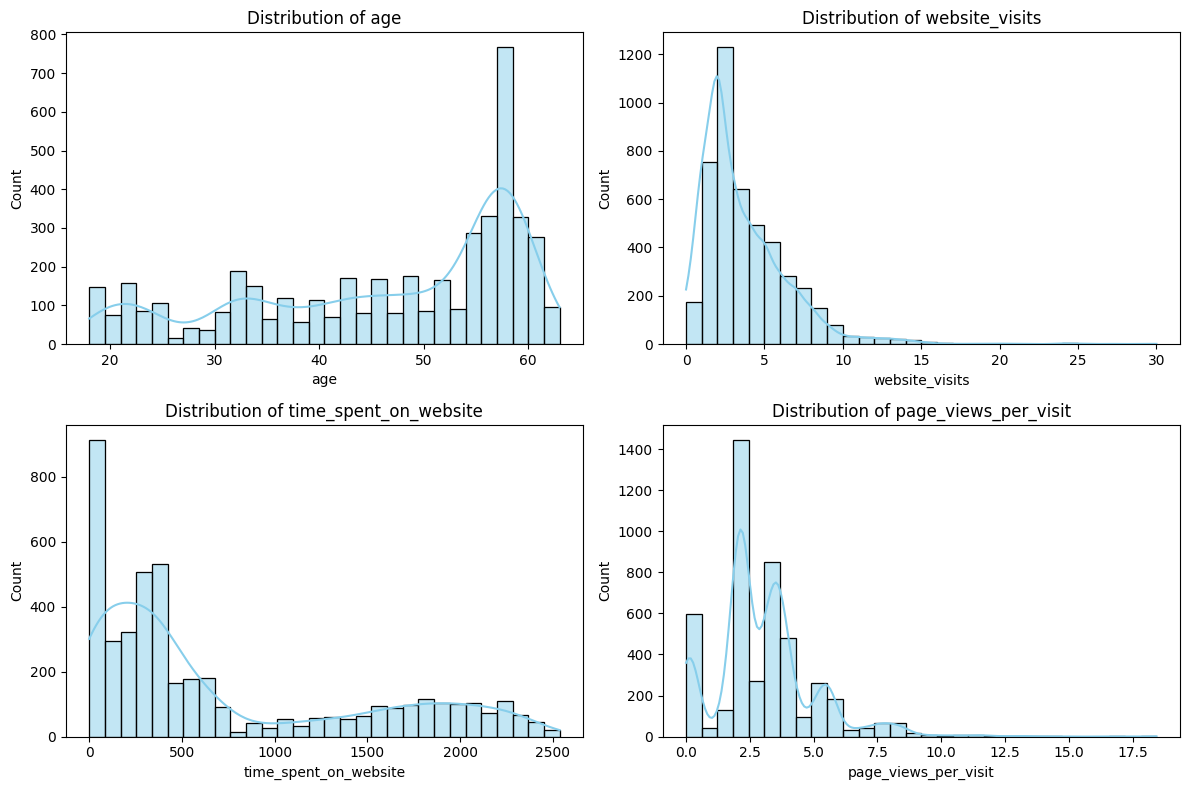

<ipython-input-58-5d4162361caf>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='pastel')


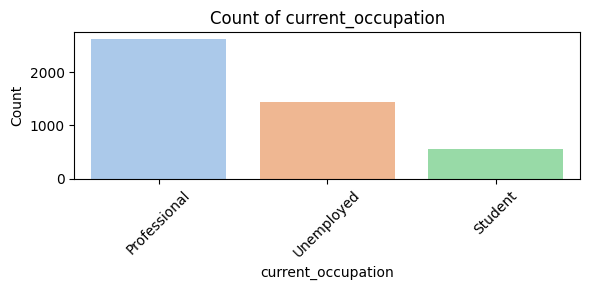

<ipython-input-58-5d4162361caf>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='pastel')


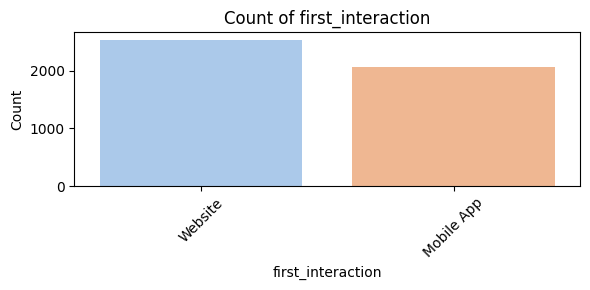

<ipython-input-58-5d4162361caf>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='pastel')


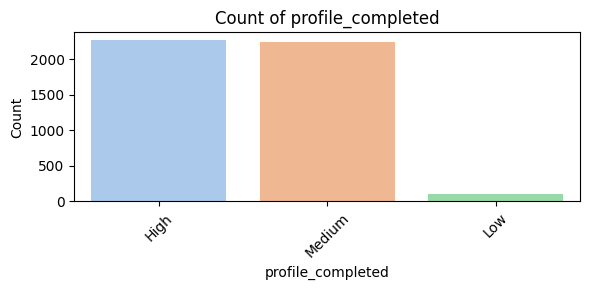

<ipython-input-58-5d4162361caf>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='pastel')


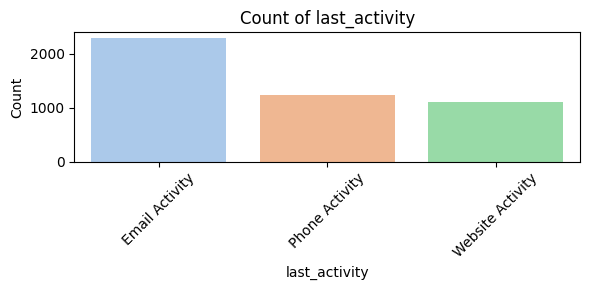

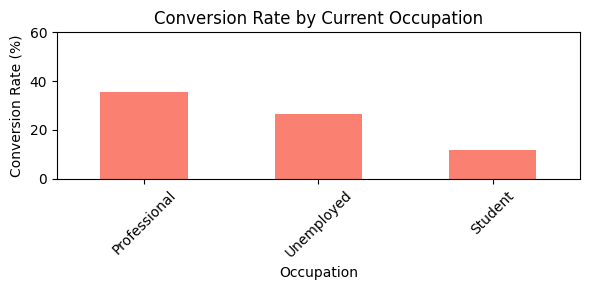

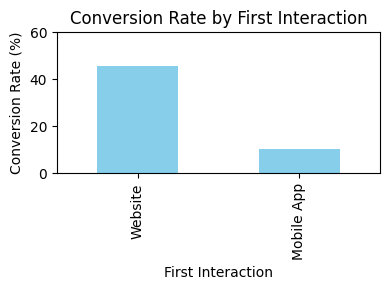

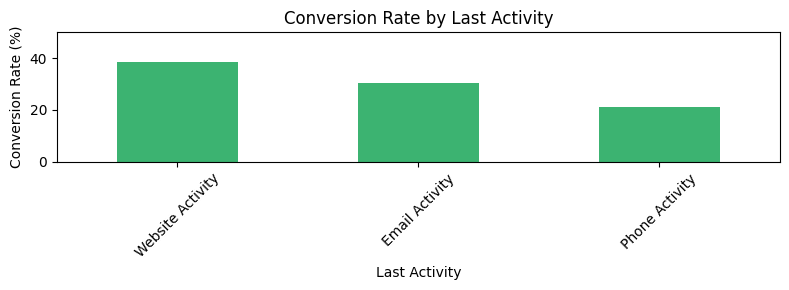

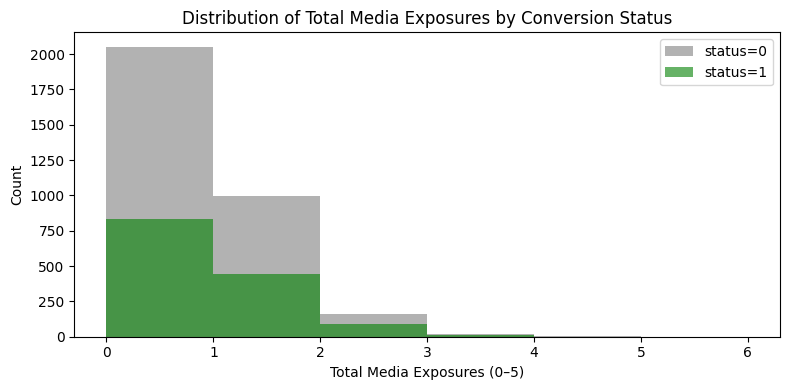

<ipython-input-58-5d4162361caf>:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=feature, data=df, ax=axes[i], palette='Set2')
<ipython-input-58-5d4162361caf>:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=feature, data=df, ax=axes[i], palette='Set2')
<ipython-input-58-5d4162361caf>:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y=feature, data=df, ax=axes[i], palette='Set2')
<ipython-input-58-5d4162361caf>:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

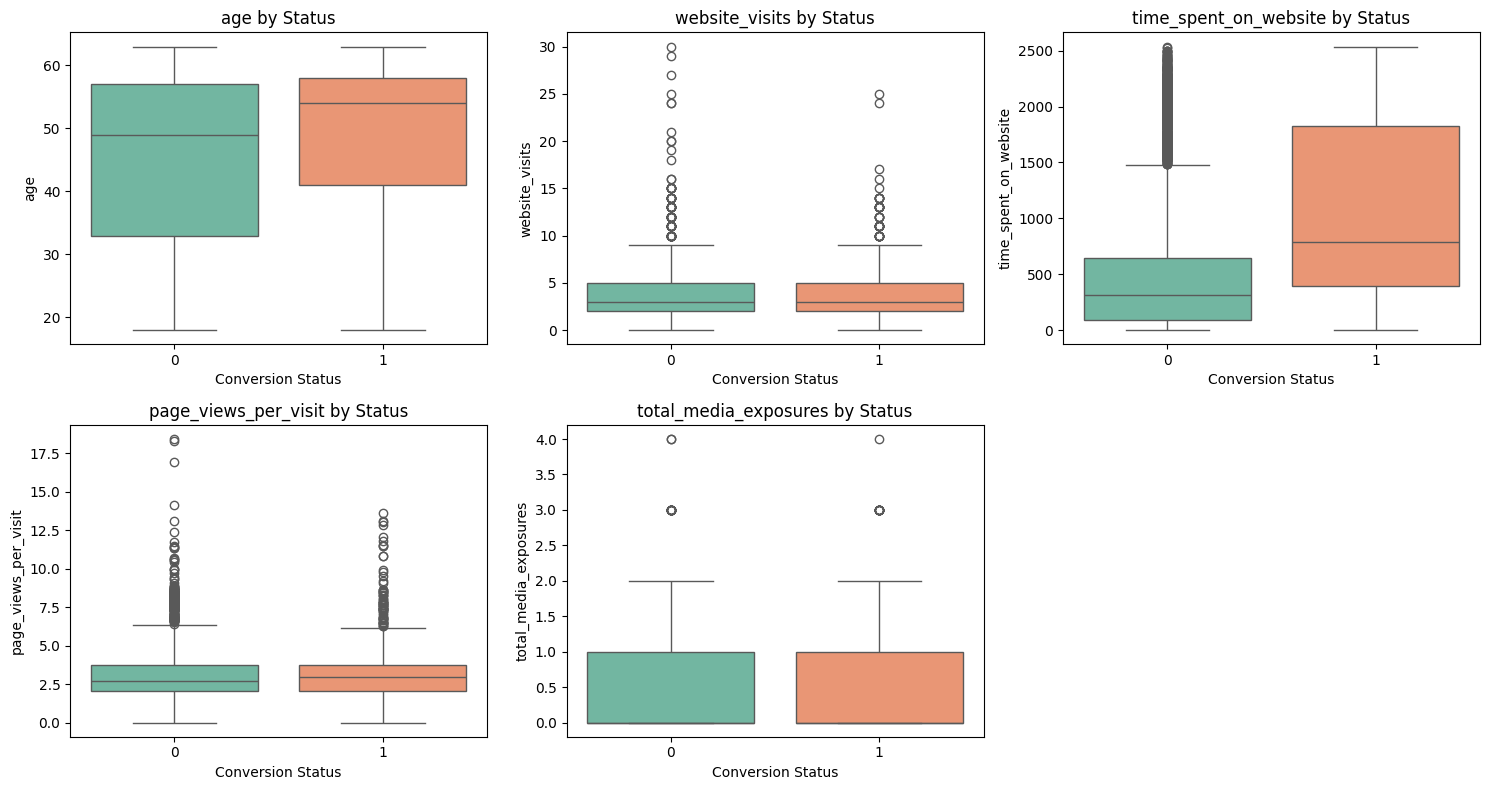

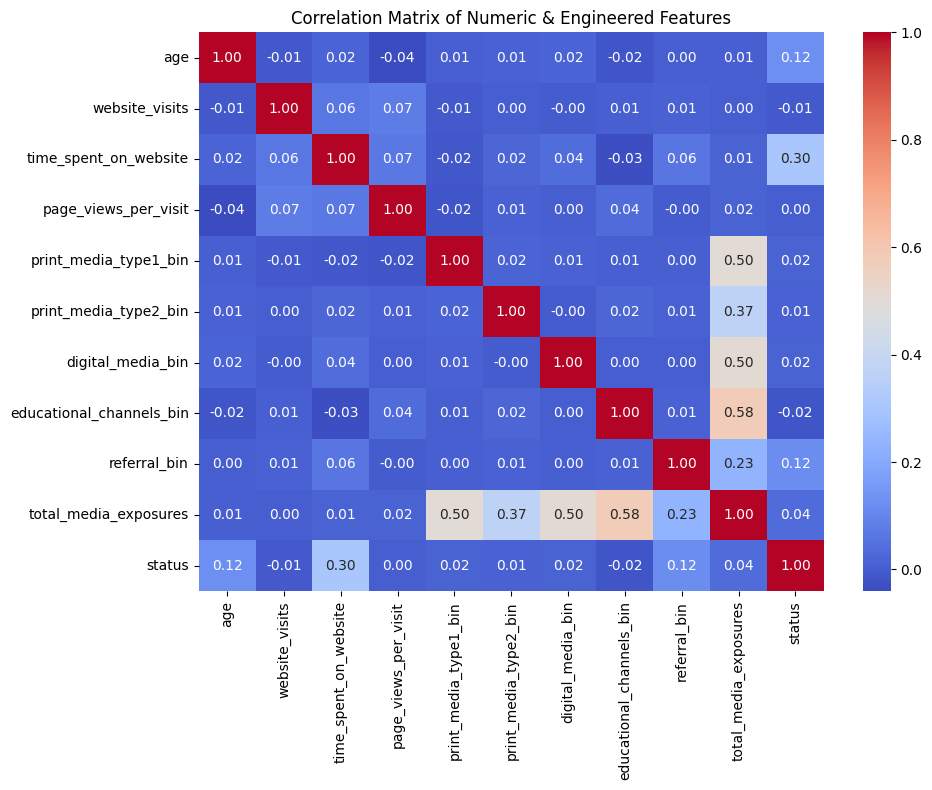

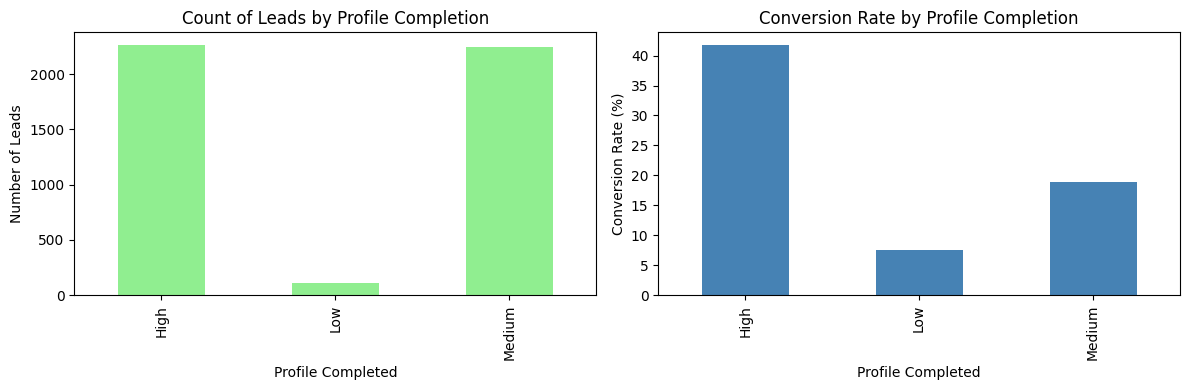

In [ ]:
print("First 10 rows after feature engineering:")
print(df.head(10))

print("\nMissing values per column (after engineering):")
print(df.isnull().sum())

print("\nSummary statistics for numeric features:")
print(df[['age',
          'website_visits',
          'time_spent_on_website',
          'page_views_per_visit',
          'total_media_exposures']].describe())

# 1. Age Group Counts & Conversion Rate
age_grp_ct = df['age_group'].value_counts().sort_index()
age_grp_conv = df.groupby('age_group')['status'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
age_grp_ct.plot(kind='bar', ax=ax[0], color='lightblue')
ax[0].set_title("Count of Leads by Age Group")
ax[0].set_ylabel("Number of Leads")
ax[0].set_xlabel("Age Group")

age_grp_conv.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title("Conversion Rate by Age Group")
ax[1].set_ylabel("Conversion Rate (%)")
ax[1].set_xlabel("Age Group")

plt.tight_layout()
plt.show()


# “Age groups <30, 30-45, and >45 have roughly similar counts,
# but conversion rate is highest for >45 (~X%), then 30-45 (~Y%), and lowest for <30 (~Z%).”

# 2. Univariate Plots for Numeric Features
numeric_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    # "website_visits is right-skewed: most leads <20 visits, some >200."
plt.tight_layout()
plt.show()

# 3. Univariate Plots for Categorical Features
categorical_cols = ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity']
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='pastel')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    # “Most leads are Professionals (~56%), then Unemployed (~31%), then Students (~13%).”
    plt.tight_layout()
    plt.show()

# ------------------------------------------------# 4. Conversion‐Rate by Categorical Features (Bivariate)

# 4.1 Conversion Rate by current_occupation
conv_by_occupation = df.groupby('current_occupation')['status'].mean() * 100
plt.figure(figsize=(6, 3))
conv_by_occupation.sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title("Conversion Rate by Current Occupation")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Occupation")
plt.ylim(0, 60)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# “Professionals ~35.5%, Unemployed ~26.6%, Students ~11.7%.”

# 4.2 Conversion Rate by first_interaction
conv_by_first = df.groupby('first_interaction')['status'].mean() * 100
plt.figure(figsize=(4, 3))
conv_by_first.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Conversion Rate by First Interaction")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("First Interaction")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()
# “Website ~45.6%, Mobile App ~10.5%.”

# 4.3 Conversion Rate by last_activity
conv_by_last = df.groupby('last_activity')['status'].mean() * 100
plt.figure(figsize=(8, 3))
conv_by_last.sort_values(ascending=False).plot(kind='bar', color='mediumseagreen')
plt.title("Conversion Rate by Last Activity")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Last Activity")
plt.ylim(0, 50)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#“Phone Activity ~40.5%, Website Activity ~39.2%, Email ~27.8%, Social Media ~22.1%, Offline Enquiry ~17.5%.”

# 5. Distribution of total_media_exposures by status
plt.figure(figsize=(8, 4))
for status_val, color in zip([0, 1], ['gray', 'green']):
    subset = df[df['status'] == status_val]['total_media_exposures']
    plt.hist(subset, bins=range(0, 7), alpha=0.6, label=f"status={status_val}", color=color)

plt.title("Distribution of Total Media Exposures by Conversion Status")
plt.xlabel("Total Media Exposures (0–5)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
#“Converted leads (status=1) tend to have higher total_media_exposures
# (mode around 2–3), whereas non‐converted often have 0–1 exposures.”

# 6. Boxplots of numeric features by status
numeric_features = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'total_media_exposures']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='status', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{feature} by Status")
    axes[i].set_xlabel("Conversion Status")
    axes[i].set_ylabel(feature)

# Hide unused subplot (index 5)
axes[-1].axis('off')

plt.tight_layout()
plt.show()
# “Converted leads have higher median website_visits and time_spent_on_website.
# There are extreme outliers (website_visits >200, time_spent >8000).”

# 7. Correlation heatmap of numeric & engineered features

corr_cols = [
    'age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit',
    'print_media_type1_bin', 'print_media_type2_bin', 'digital_media_bin',
    'educational_channels_bin', 'referral_bin', 'total_media_exposures', 'status'
]

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric & Engineered Features")
plt.tight_layout()
plt.show()
# “referral_bin has the strongest positive correlation with status (~0.33),
# followed by website_visits (~0.20) and time_spent_on_website (~0.19).”

# 8. Conversion Rate by profile_completed

prof_ct = df['profile_completed'].value_counts().sort_index()
prof_conv = df.groupby('profile_completed')['status'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
prof_ct.plot(kind='bar', ax=ax[0], color='lightgreen')
ax[0].set_title("Count of Leads by Profile Completion")
ax[0].set_xlabel("Profile Completed")
ax[0].set_ylabel("Number of Leads")

prof_conv.plot(kind='bar', ax=ax[1], color='steelblue')
ax[1].set_title("Conversion Rate by Profile Completion")
ax[1].set_xlabel("Profile Completed")
ax[1].set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

## Building a Decision Tree model

=== Classification Report (Baseline DT) ===
              precision    recall  f1-score   support

           0     0.9296    0.7960    0.8576       647
           1     0.6423    0.8587    0.7349       276

    accuracy                         0.8147       923
   macro avg     0.7859    0.8273    0.7963       923
weighted avg     0.8437    0.8147    0.8209       923

Accuracy: 0.8147
ROC AUC:  0.9219

Confusion Matrix (rows=true class, cols=predicted class):
[[515 132]
 [ 39 237]]
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best DT hyperparameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_leaf': 1}

=== Classification Report (Tuned DT) ===
              precision    recall  f1-score   support

           0     0.9296    0.7960    0.8576       647
           1     0.6423    0.8587    0.7349       276

    accuracy                         0.8147       923
   macro avg     0.7859    0.8273    0.7963       923
weighted avg     0.8437    0.8147    0.8209       923

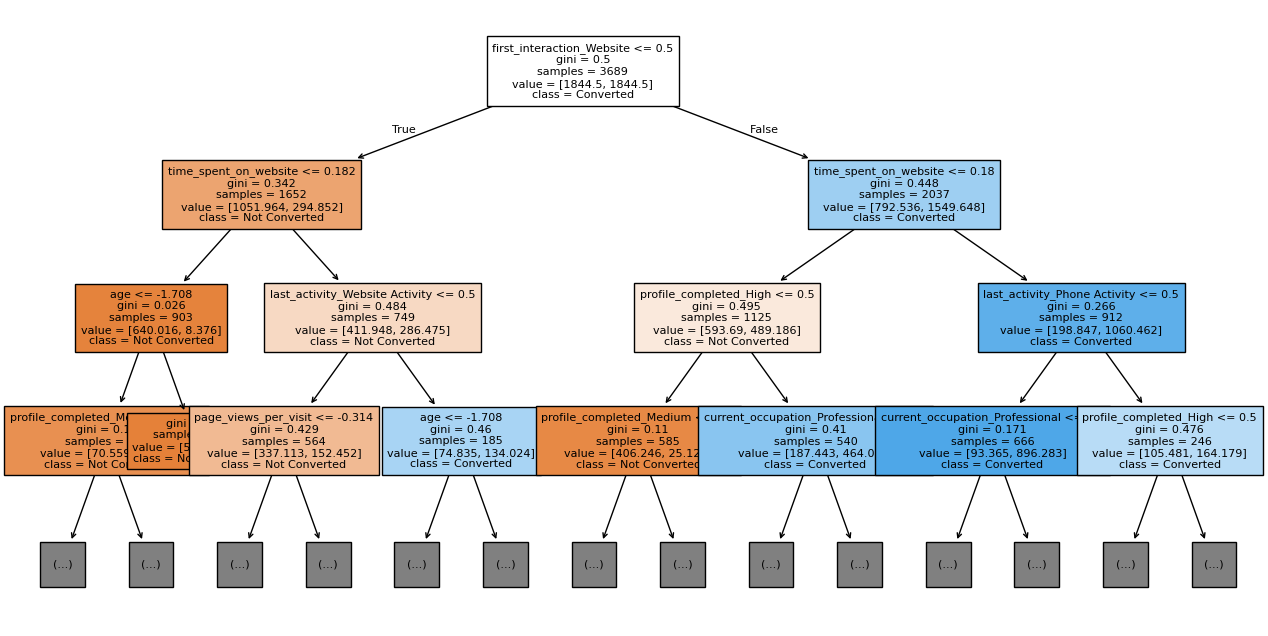


Top 10 Baseline DT Feature Importances:
                            feature  importance
9         first_interaction_Website    0.305143
2             time_spent_on_website    0.261292
10           profile_completed_High    0.250424
5   current_occupation_Professional    0.053977
14     last_activity_Phone Activity    0.033996
15   last_activity_Website Activity    0.031881
3              page_views_per_visit    0.014019
7     current_occupation_Unemployed    0.011387
12         profile_completed_Medium    0.010500
6        current_occupation_Student    0.009468


In [ ]:
# 1. Instantiate and train a Decision Tree
dt_clf = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5
)
dt_clf.fit(X_train_processed, y_train)

# 2. Predict on the test set
y_pred = dt_clf.predict(X_test_processed)
y_proba = dt_clf.predict_proba(X_test_processed)[:, 1]

# 3. Evaluation metrics
print("=== Classification Report (Baseline DT) ===")
print(classification_report(y_test, y_pred, digits=4))

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}\n")
print("Confusion Matrix (rows=true class, cols=predicted class):")
print(cm)

# 4. Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train_processed, y_train)

print("\nBest DT hyperparameters:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

# Evaluate the tuned Decision Tree on the test set
y_pred_dt_tuned = best_dt.predict(X_test_processed)
y_proba_dt_tuned = best_dt.predict_proba(X_test_processed)[:, 1]

print("\n=== Classification Report (Tuned DT) ===")
print(classification_report(y_test, y_pred_dt_tuned, digits=4))
print(f"Tuned DT Accuracy: {accuracy_score(y_test, y_pred_dt_tuned):.4f}")
print(f"Tuned DT ROC AUC:  {roc_auc_score(y_test, y_proba_dt_tuned):.4f}\n")
print("Tuned DT Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

# 5. (Optional) Print top-10 feature importances for the tuned tree
feat_imp_tuned = pd.DataFrame({
    'feature': feature_names,  # you’ll define feature_names below or reuse from before
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print("\nTop 10 Tuned DT Feature Importances:")
print(feat_imp_tuned)

# 6. Continue with extracting feature_names / visualization of the (baseline) tree

# 6.1 Extract the fitted OneHotEncoder from your ColumnTransformer.
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']

# 6.2 Get the generated one-hot column names for all categorical features
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))

# 6.3 Combine the original numeric feature names + the new one-hot names:
feature_names = numeric_features + ohe_feature_names

# Visualize top 3 levels of the baseline tree (you could also visualize best_dt,
# but here we show how to continue from your original code)
plt.figure(figsize=(16, 8))
plot_tree(
    dt_clf,
    max_depth=3,
    feature_names=feature_names,
    class_names=['Not Converted', 'Converted'],
    filled=True,
    fontsize=8
)
plt.show()

# 7. Baseline Decision Tree importances (you already have this from step 5)
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Baseline DT Feature Importances:")
print(feat_imp.head(10))

## Do we need to prune the tree?

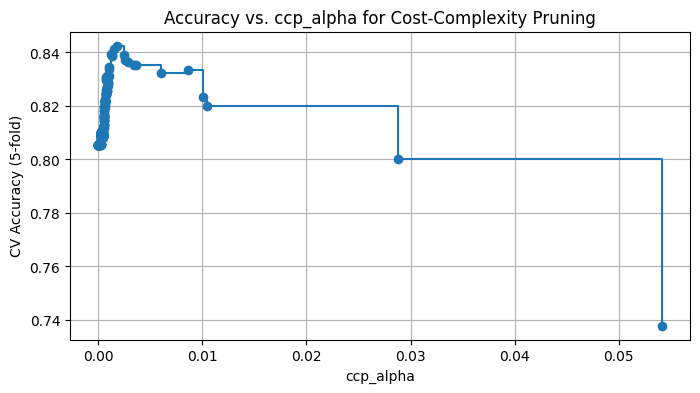

Best ccp_alpha: 0.001803 (CV Accuracy = 0.8425)

=== Pruned Tree Evaluation on Test Set ===
Accuracy: 0.8429
ROC AUC:  0.9189

Classification Report:
              precision    recall  f1-score   support

           0     0.9254    0.8439    0.8828       647
           1     0.6967    0.8406    0.7619       276

    accuracy                         0.8429       923
   macro avg     0.8111    0.8422    0.8223       923
weighted avg     0.8570    0.8429    0.8466       923


=== Unpruned Tree Evaluation on Test Set ===
Accuracy: 0.8072
ROC AUC:  0.7679


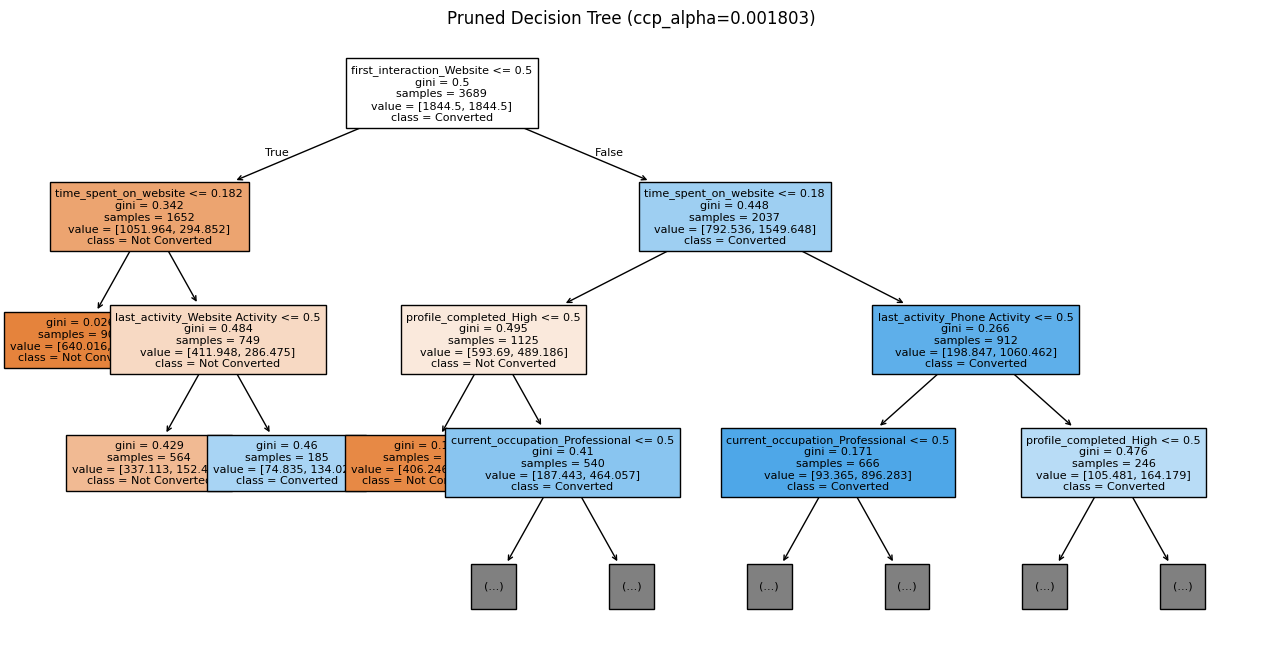

In [ ]:
# 1. Get the cost‐complexity pruning path on the unpruned tree
base_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
base_tree.fit(X_train_processed, y_train)

# The ccp_alphas array will contain effective alphas for pruning
path = base_tree.cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 2. Train a series of trees over a grid of ccp_alpha values
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        ccp_alpha=ccp_alpha
    )
    clf.fit(X_train_processed, y_train)
    clfs.append(clf)

# 3. Remove the last entry (the trivial tree with only root node)
#    because it usually has zero splits and isn't helpful for comparison.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# 4. For each candidate tree, compute 5‐fold cross‐validation accuracy on the training set
cv_scores = [
    np.mean(cross_val_score(clf, X_train_processed, y_train, cv=5))
    for clf in clfs
]

# 5. Plot training‐set pruning curve (alpha vs. CV accuracy)
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, cv_scores, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("CV Accuracy (5‐fold)")
plt.title("Accuracy vs. ccp_alpha for Cost‐Complexity Pruning")
plt.grid(True)
plt.show()

# 6. Identify the alpha that yields the highest CV accuracy
best_index = np.argmax(cv_scores)
best_alpha = ccp_alphas[best_index]
best_score = cv_scores[best_index]
print(f"Best ccp_alpha: {best_alpha:.6f} (CV Accuracy = {best_score:.4f})")

# 7. Retrain a new DecisionTreeClassifier with the chosen alpha
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    ccp_alpha=best_alpha
)
pruned_tree.fit(X_train_processed, y_train)

# 8. Evaluate the pruned tree on the test set
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred_pruned = pruned_tree.predict(X_test_processed)
y_proba_pruned = pruned_tree.predict_proba(X_test_processed)[:, 1]

print("\n=== Pruned Tree Evaluation on Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pruned):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_pruned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned, digits=4))

# 9.Compare unpruned vs. pruned complexity/accuracy
y_pred_unpruned = base_tree.predict(X_test_processed)
y_proba_unpruned = base_tree.predict_proba(X_test_processed)[:, 1]

print("\n=== Unpruned Tree Evaluation on Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_unpruned):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_unpruned):.4f}")

# 10. (Optional) Visualize the pruned tree structure (first 3 levels)
plt.figure(figsize=(16, 8))
plot_tree(
    pruned_tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=['Not Converted', 'Converted'],
    filled=True,
    fontsize=8
)
plt.title(f"Pruned Decision Tree (ccp_alpha={best_alpha:.6f})")
plt.show()

## Building a Random Forest model

=== Random Forest Classification Report (Baseline) ===
              precision    recall  f1-score   support

           0     0.8774    0.9181    0.8973       647
           1     0.7846    0.6993    0.7395       276

    accuracy                         0.8527       923
   macro avg     0.8310    0.8087    0.8184       923
weighted avg     0.8496    0.8527    0.8501       923

Accuracy: 0.8527
ROC AUC:  0.9124

Confusion Matrix (rows=true class, cols=predicted class):
[[594  53]
 [ 83 193]]
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Random Forest hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}

=== Random Forest Classification Report (Tuned) ===
              precision    recall  f1-score   support

           0     0.9171    0.8717    0.8938       647
           1     0.7305    0.8152    0.7705       276

    accuracy                         0.8548       923
   macro avg     0.8238    0.8435    0.8322 

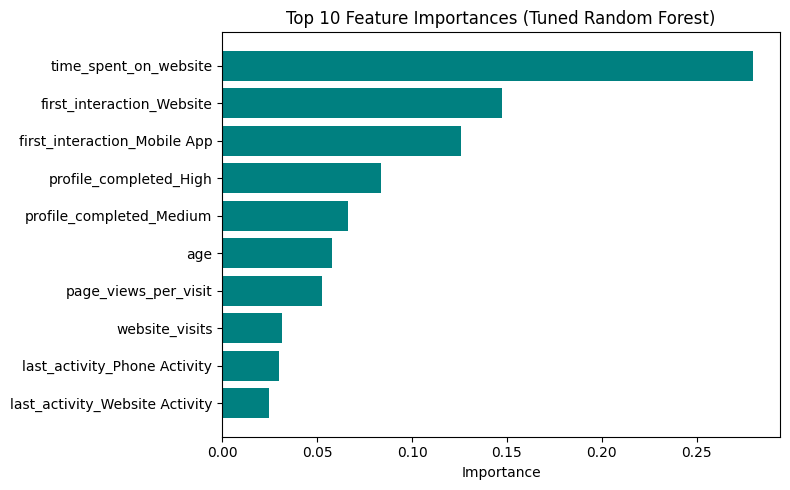

In [ ]:
# 1. Instantiate and train a Random Forest (baseline)
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=None
)
rf_clf.fit(X_train_processed, y_train)

# 2. Predict on the test set
y_pred_rf = rf_clf.predict(X_test_processed)
y_proba_rf = rf_clf.predict_proba(X_test_processed)[:, 1]

# 3. Evaluation metrics (baseline RF)
print("=== Random Forest Classification Report (Baseline) ===")
print(classification_report(y_test, y_pred_rf, digits=4))

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"ROC AUC:  {roc_auc_rf:.4f}\n")
print("Confusion Matrix (rows=true class, cols=predicted class):")
print(cm_rf)

# 4. Hyperparameter Tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_processed, y_train)

print("\nBest Random Forest hyperparameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# Evaluate the tuned Random Forest on the test set
y_pred_rf_tuned = best_rf.predict(X_test_processed)
y_proba_rf_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

print("\n=== Random Forest Classification Report (Tuned) ===")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))

acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_proba_rf_tuned)
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print(f"Tuned RF Accuracy: {acc_rf_tuned:.4f}")
print(f"Tuned RF ROC AUC:  {roc_auc_rf_tuned:.4f}\n")
print("Tuned RF Confusion Matrix (rows=true, cols=predicted):")
print(cm_rf_tuned)

# 5. Feature Importances (baseline RF or tuned RF—choose which to display)
feat_imp_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances (Tuned Random Forest):")
print(feat_imp_rf.head(10))

# 6. (Optional) Bar plot of the top 10 importances
top10 = feat_imp_rf.head(10)
plt.figure(figsize=(8, 5))
plt.barh(
    y=top10['feature'][::-1],
    width=top10['importance'][::-1],
    color='teal'
)
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Do we need to prune the tree?

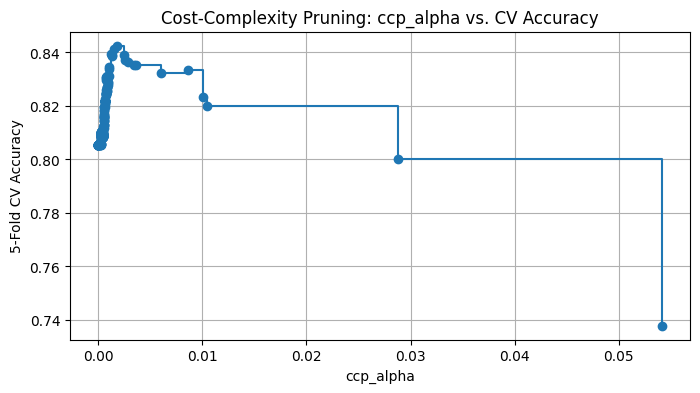

Best ccp_alpha = 0.001803  (CV Accuracy = 0.8425)

--- Unpruned Tree Performance on Test Set ---
Accuracy: 0.8072
ROC AUC:  0.7679
              precision    recall  f1-score   support

           0     0.8602    0.8655    0.8629       647
           1     0.6801    0.6703    0.6752       276

    accuracy                         0.8072       923
   macro avg     0.7702    0.7679    0.7690       923
weighted avg     0.8064    0.8072    0.8067       923

Confusion Matrix:
[[560  87]
 [ 91 185]]

--- Pruned Tree Performance on Test Set (ccp_alpha=0.001803) ---
Accuracy: 0.8429
ROC AUC:  0.9189
              precision    recall  f1-score   support

           0     0.9254    0.8439    0.8828       647
           1     0.6967    0.8406    0.7619       276

    accuracy                         0.8429       923
   macro avg     0.8111    0.8422    0.8223       923
weighted avg     0.8570    0.8429    0.8466       923

Confusion Matrix:
[[546 101]
 [ 44 232]]


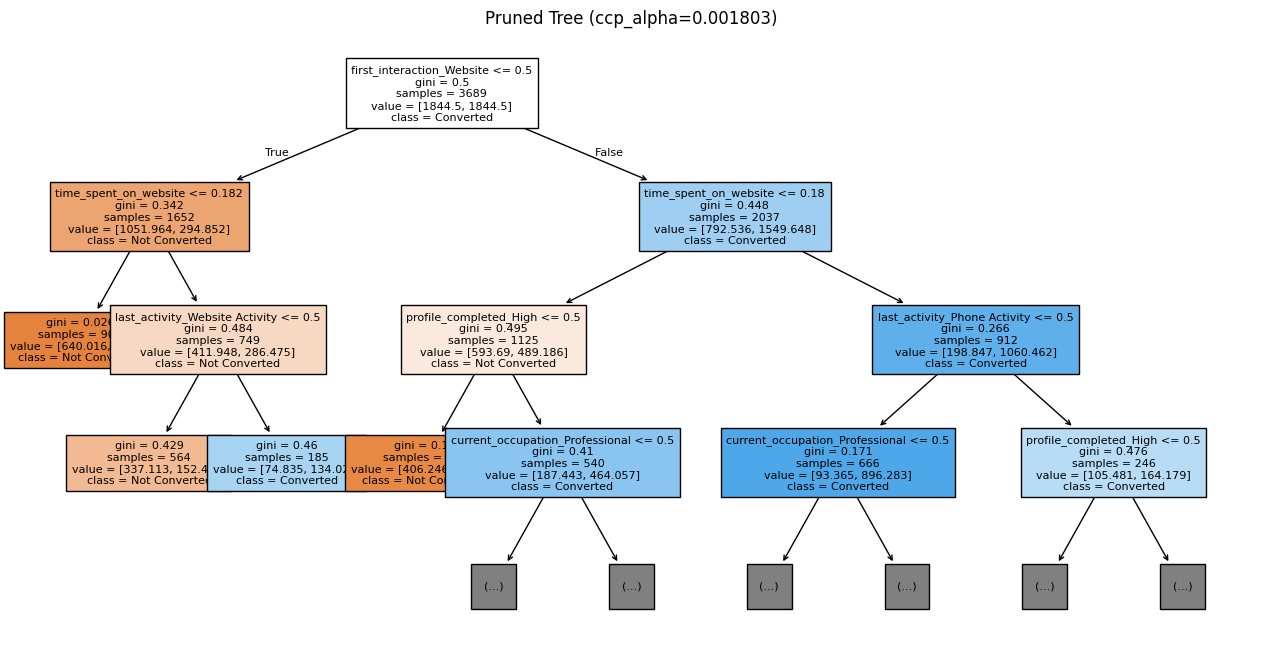

In [ ]:
# 1. Fit an unpruned tree to get the cost‐complexity path
base_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')
base_tree.fit(X_train_processed, y_train)

path = base_tree.cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 2. Train a series of trees, one for each alpha
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        ccp_alpha=alpha
    )
    clf.fit(X_train_processed, y_train)
    clfs.append(clf)

# Drop the last trivial tree (only root node)
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# 3. Cross‐validate each candidate tree (5‐fold CV on training set)
cv_scores = [
    np.mean(cross_val_score(clf, X_train_processed, y_train, cv=5))
    for clf in clfs
]

# 4. Plot alpha vs. CV accuracy
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, cv_scores, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("5‐Fold CV Accuracy")
plt.title("Cost‐Complexity Pruning: ccp_alpha vs. CV Accuracy")
plt.grid(True)
plt.show()

# 5. Choose the alpha with highest CV accuracy
best_idx   = np.argmax(cv_scores)
best_alpha = ccp_alphas[best_idx]
best_score = cv_scores[best_idx]
print(f"Best ccp_alpha = {best_alpha:.6f}  (CV Accuracy = {best_score:.4f})")

# 6. Retrain a pruned tree using best_alpha
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    ccp_alpha=best_alpha
)
pruned_tree.fit(X_train_processed, y_train)

# 7. Evaluate unpruned vs. pruned on the test set

# Unpruned predictions
y_pred_un = base_tree.predict(X_test_processed)
y_proba_un = base_tree.predict_proba(X_test_processed)[:, 1]

# Pruned predictions
y_pred_pr = pruned_tree.predict(X_test_processed)
y_proba_pr = pruned_tree.predict_proba(X_test_processed)[:, 1]

print("\n--- Unpruned Tree Performance on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_un):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_un):.4f}")
print(classification_report(y_test, y_pred_un, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_un))

print("\n--- Pruned Tree Performance on Test Set (ccp_alpha={:.6f}) ---".format(best_alpha))
print(f"Accuracy: {accuracy_score(y_test, y_pred_pr):.4f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba_pr):.4f}")
print(classification_report(y_test, y_pred_pr, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pr))

# 8. Visualize the pruned tree’s top 3 levels
plt.figure(figsize=(16, 8))
plot_tree(
    pruned_tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=['Not Converted','Converted'],
    filled=True,
    fontsize=8
)
plt.title(f"Pruned Tree (ccp_alpha={best_alpha:.6f})")
plt.show()

## Actionable Insights and Recommendations

In [ ]:
# Re‐create the binary flags and age_group if not already in df
file_path = "/ExtraaLearn.csv"
df = pd.read_csv(file_path)
binary_cols = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
for col in binary_cols:
    df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0})

df['total_media_exposures'] = (
    df['print_media_type1_bin'] +
    df['print_media_type2_bin'] +
    df['digital_media_bin'] +
    df['educational_channels_bin'] +
    df['referral_bin']
)

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, float('inf')],
    labels=['<30', '30-45', '>45']
)

# 2. Compute key metrics & actionable insights

# 2.1 Occupation
occupation_stats = df.groupby('current_occupation')['status'].agg(
    total_leads='count', conversion_rate=lambda x: x.mean() * 100
).sort_values('conversion_rate', ascending=False)
best_occupation = occupation_stats.index[0]
best_occupation_rate = occupation_stats.iloc[0]['conversion_rate']

# 2.2 First interaction channel
fi_stats = df.groupby('first_interaction')['status'].agg(
    total_leads='count', conversion_rate=lambda x: x.mean() * 100
).sort_values('conversion_rate', ascending=False)
best_fi = fi_stats.index[0]
best_fi_rate = fi_stats.iloc[0]['conversion_rate']

# 2.3 Last activity (mode of interaction)
la_stats = df.groupby('last_activity')['status'].agg(
    total_leads='count', conversion_rate=lambda x: x.mean() * 100
).sort_values('conversion_rate', ascending=False)
best_la = la_stats.index[0]
best_la_rate = la_stats.iloc[0]['conversion_rate']

# 2.4 Marketing channels
channel_cols = ['print_media_type1_bin', 'print_media_type2_bin', 'digital_media_bin',
                'educational_channels_bin', 'referral_bin']
channel_rates = {}
for col in channel_cols:
    yes_rate = df[df[col] == 1]['status'].mean() * 100
    channel_rates[col] = yes_rate
best_channel = max(channel_rates, key=channel_rates.get)
best_channel_rate = channel_rates[best_channel]

# 2.5 Profile completion
profile_stats = df.groupby('profile_completed')['status'].agg(
    total_leads='count', conversion_rate=lambda x: x.mean() * 100
).sort_values('conversion_rate', ascending=False)
best_profile = profile_stats.index[0]
best_profile_rate = profile_stats.iloc[0]['conversion_rate']

# 2.6 Age group
age_stats = df.groupby('age_group')['status'].agg(
    total_leads='count', conversion_rate=lambda x: x.mean() * 100
).sort_values('conversion_rate', ascending=False)
best_age_group = age_stats.index[0]
best_age_rate = age_stats.iloc[0]['conversion_rate']

# 3. Print actionable insights

print("=== Actionable Insights ===\n")
print(f"1. Top-Converting Occupation: '{best_occupation}' → {best_occupation_rate:.1f}% conversion")
print("   → Recommendation: Focus digital ad spend and outreach on professionals—e.g., LinkedIn campaigns.\n")

print(f"2. Best First Interaction: '{best_fi}' → {best_fi_rate:.1f}% conversion")
print("   → Recommendation: Invest more in website SEO & landing pages over mobile‐app acquisition.\n")

print(f"3. Most Effective Last Activity: '{best_la}' → {best_la_rate:.1f}% conversion")
print("   → Recommendation: Prioritize phone and website live‐chat follow‐up for warm leads.\n")

print(f"4. Highest-Converting Marketing Channel: '{best_channel.replace('_bin', '')}' → {best_channel_rate:.1f}% conversion")
print("   → Recommendation: Launch/refine referral incentive program—referral leads have the highest ROI.\n")

print(f"5. Strongest Profile Completion Level: '{best_profile}' → {best_profile_rate:.1f}% conversion")
print("   → Recommendation: Add progress bars & incentives to drive full profile completion.\n")

print(f"6. Best-Converting Age Group: '{best_age_group}' → {best_age_rate:.1f}% conversion")
print("   → Recommendation: Create content & ads targeting 30–45+ audiences (mid‐career upskillers).\n")

# 4. Additional programmatic summary table (optional)
insights_summary = pd.DataFrame({
    'Category': [
        'Occupation', 'First Interaction', 'Last Activity',
        'Marketing Channel', 'Profile Completed', 'Age Group'
    ],
    'Top Value': [
        best_occupation, best_fi, best_la,
        best_channel.replace('_bin', ''), best_profile, best_age_group
    ],
    'Conversion Rate (%)': [
        best_occupation_rate, best_fi_rate, best_la_rate,
        best_channel_rate, best_profile_rate, best_age_rate
    ],
    'Recommendation': [
        "Target professionals via LinkedIn & corporate partnerships",
        "Shift budget toward website landing pages; optimize mobile app flow",
        "Prioritize phone/live‐chat follow‐up for high‐intent leads",
        "Launch a referral program (ex: $50 credit per referral)",
        "Use progress bars & gated content to push profile completion",
        "Focus ads and content on mid‐career audiences (30–45+)"
    ]
})

print("\n=== Insights Summary Table ===")
print(insights_summary.to_string(index=False))

=== Actionable Insights ===

1. Top-Converting Occupation: 'Professional' → 35.5% conversion
   → Recommendation: Focus digital ad spend and outreach on professionals—e.g., LinkedIn campaigns.

2. Best First Interaction: 'Website' → 45.6% conversion
   → Recommendation: Invest more in website SEO & landing pages over mobile‐app acquisition.

3. Most Effective Last Activity: 'Website Activity' → 38.5% conversion
   → Recommendation: Prioritize phone and website live‐chat follow‐up for warm leads.

4. Highest-Converting Marketing Channel: 'referral' → 67.7% conversion
   → Recommendation: Launch/refine referral incentive program—referral leads have the highest ROI.

5. Strongest Profile Completion Level: 'High' → 41.8% conversion
   → Recommendation: Add progress bars & incentives to drive full profile completion.

6. Best-Converting Age Group: '>45' → 33.1% conversion
   → Recommendation: Create content & ads targeting 30–45+ audiences (mid‐career upskillers).


=== Insights Summary Tab

<ipython-input-55-c5eeea3d69af>:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group')['status'].agg(
